In [1]:
from nested_pandas import read_parquet
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
outdir = Path('outputs/')

In [2]:
ddf = read_parquet(outdir / "final_sample_ddf.parquet")
full = read_parquet(outdir / "final_sample.parquet")

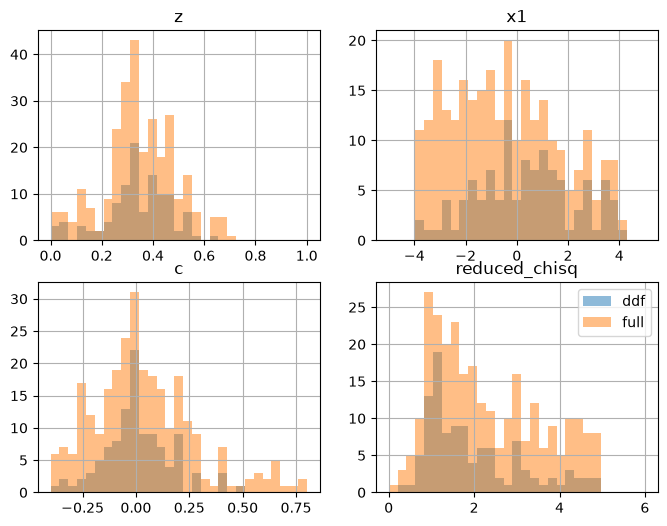

In [3]:
fig = plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
bins = np.linspace(0,1,30)
ddf.z.hist(bins=bins, label="ddf",alpha=0.5)
full.z.hist(bins=bins, label="full",alpha=0.5)
plt.title("z")
plt.subplot(2,2,2)
bins = np.linspace(-5,5,30)
ddf.x1.hist(bins=bins, label="ddf",alpha=0.5)
full.x1.hist(bins=bins, label="full",alpha=0.5)
plt.title("x1")
plt.subplot(2,2,3)
bins = np.linspace(-0.4,0.8,30)
ddf.c.hist(bins=bins, label="ddf",alpha=0.5)
full.c.hist(bins=bins, label="full",alpha=0.5)
plt.title("c")
plt.subplot(2,2,4)
bins = np.linspace(0,6,30)
ddf.reduced_chisq.hist(bins=bins, label="ddf",alpha=0.5)
full.reduced_chisq.hist(bins=bins, label="full",alpha=0.5)
plt.title("reduced_chisq")
plt.legend()
plt.show()

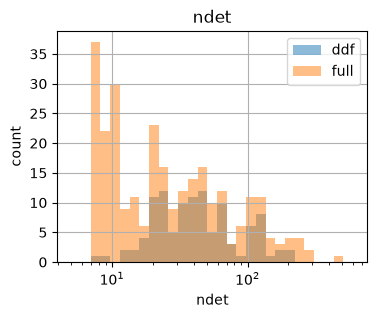

In [13]:
fig = plt.figure(figsize=(4,3))
bins = np.logspace(np.log10(5), np.log10(600), 30)  # avoid 0 for log bins
ddf["ndet"].hist(bins=bins, label="ddf", alpha=0.5)
full["ndet"].hist(bins=bins, label="full", alpha=0.5)
plt.xscale('log')
plt.xlabel("ndet")
plt.ylabel("count")
plt.legend()
plt.title("ndet")
plt.show()

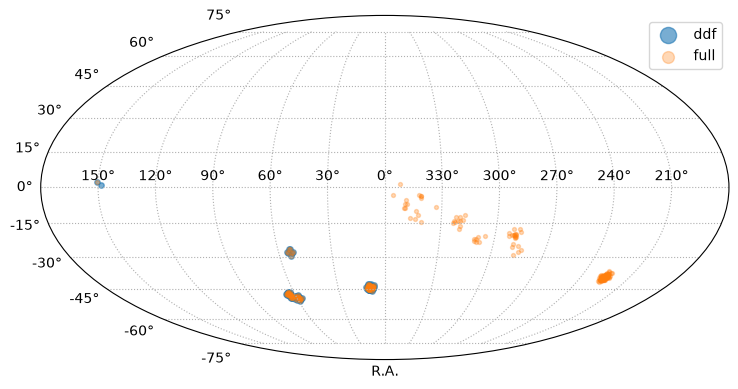

In [31]:
CENTER = 0

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111, projection='mollweide')

def plot_radec(ra, dec, center=CENTER, flip=True, **kwargs):
    ra = np.asarray(ra, dtype=float)
    dec = np.asarray(dec, dtype=float)
    ra_shifted = np.remainder(ra - center + 180, 360) - 180
    x = -ra_shifted if flip else ra_shifted
    ax.scatter(np.radians(x), np.radians(dec), **kwargs)

plot_radec(ddf["ra_dia_object_lc"].to_numpy(dtype=float), ddf["dec_dia_object_lc"].to_numpy(dtype=float),
           s=15, alpha=0.6, label="ddf")
plot_radec(full["ra_dia_object_lc"].to_numpy(dtype=float), full["dec_dia_object_lc"].to_numpy(dtype=float),
           s=8, alpha=0.3, label="full")

tick_vals = np.array([-150,-120,-90,-60,-30,0,30,60,90,120,150])
tick_labels = [f"{int(np.remainder(CENTER - t, 360))}°" for t in tick_vals]
ax.set_xticks(np.radians(tick_vals))
ax.set_xticklabels(tick_labels)

ax.grid(True, linestyle=':')
ax.legend(markerscale=3, loc='upper right')
ax.set_xlabel("R.A.")
plt.tight_layout()
plt.show()

In [30]:
col = "diaObjectId_dia_object_lc"  # change to whatever column

set_ddf = set(ddf[col].dropna())
set_full = set(full[col].dropna())

overlap = set_ddf & set_full

print(f"ddf: {len(set_ddf)} unique values")
print(f"full: {len(set_full)} unique values")
print(f"overlap: {len(overlap)} values")
print(f"overlap fraction of ddf: {len(overlap)/len(set_ddf):.2%}")
print(f"overlap fraction of full: {len(overlap)/len(set_full):.2%}")

ddf: 109 unique values
full: 276 unique values
overlap: 105 values
overlap fraction of ddf: 96.33%
overlap fraction of full: 38.04%
